In [1]:
RUN_TEST = False # a toggle to run the single bootstrap sample test run
RUN_FIRST_TIME = False # a toggle to have everything actually train. false means it just imports a pickle file

# Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('senate_general_indiv20.csv', dtype=str)

df['TRANSACTION_AMT'] = df['TRANSACTION_AMT'].astype(float)

df.head()

,CMTE_ID,IMAGE_NUM,TRANSACTION_TP,NAME,CITY,STATE,ZIP_CODE,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,CAND_ID,CAND_NAME,CAND_PTY_AFFILIATION,CAND_OFFICE_ST
0,C00647842,202010089285059826,15,"LOMBARDO, ROBERT",MANCHESTER,NH,03102,ELECTRONICS FOR IMAGING INC,TRADE COMPLIANCE MANAGER,2020-09-08,275.0,S0NH00300,"O'DONNELL, JUSTIN F",LIB,NH
1,C00716340,202010089285059649,15,"FLOYD, WILLIAM",EVANSTON,IL,60201,RETIRED,RETIRED,2020-09-10,500.0,S0IL00543,"CURRAN, MARK",REP,IL
2,C00716340,202010089285059651,15,"GULLY, MICHAEL",QUINCY,IL,62305,GULLY TRANSPORTATION,TRUCK LINE EXECUTIVE,2020-09-07,1000.0,S0IL00543,"CURRAN, MARK",REP,IL
3,C00716340,202010089285059651,15,"GULLY, MICHAEL",QUINCY,IL,62305,GULLY TRANSPORTATION,TRUCK LINE EXECUTIVE,2020-09-07,250.0,S0IL00543,"CURRAN, MARK",REP,IL
4,C00716340,202010089285059661,15,"O'BRIEN, KATHLEEN",LAKE FOREST,IL,60045,SELF,ATTORNEY,2020-09-02,250.0,S0IL00543,"CURRAN, MARK",REP,IL


# Wrangle data to correct form

Want one row <-> one zip code, with outcome=[summed donations] and covariate_options=[num_donors, proportion_donations_republican, state_fixed_effect]. Remains to be seen whether we want to use number of donors or state fixed effect. Will drop non-democrat or republican donations (won't really matter; it's less than 1% of donations anyway.)

In [3]:
# --- party proportions ---
party_totals = (
    df.groupby(['ZIP_CODE', 'CAND_PTY_AFFILIATION'])['TRANSACTION_AMT']
    .sum()
    .unstack(fill_value=0)
)
party_props = party_totals.div(party_totals.sum(axis=1), axis=0)
party_props = party_props.rename(columns={'REP': 'prop_rep', 'DEM': 'prop_dem'})
keep = ['prop_rep', 'prop_dem']
for col in keep:
    if col not in party_props.columns:
        party_props[col] = 0.0
party_props = party_props[keep].reset_index()

# --- main aggregation ---
zip_df = df.groupby('ZIP_CODE').agg(
    total_amt=('TRANSACTION_AMT', 'sum'),
    n_donors=('NAME', 'nunique'),
    state=('STATE', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan) # mode in case there are shenanigans
).reset_index()

# --- merge ---
zip_df = zip_df.merge(party_props, on='ZIP_CODE', how='left')

# --- transforms ---
zip_df['log_total_amt'] = np.log1p(zip_df['total_amt'])
zip_df['log_n_donors'] = np.log(zip_df['n_donors'])

# --- state dummies ---
state_dummies = pd.get_dummies(zip_df['state'], prefix='state', drop_first=True)
zip_df = pd.concat([zip_df, state_dummies], axis=1)

print(zip_df.shape)

(354479, 66)


/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
# add geodata
import pgeocode

nomi = pgeocode.Nominatim('us')
geo_info = nomi.query_postal_code(zip_df['ZIP_CODE'].tolist())

zip_df['lat'] = geo_info['latitude'].values
zip_df['lon'] = geo_info['longitude'].values

zip_df.head()

# drop if no geodata
pre_len = len(zip_df)
zip_df = zip_df.dropna(subset=['lat', 'lon'])
print('Number removed for missing geodata: ', pre_len - len(zip_df))

# drop if not in contiguous USA
pre_len = len(zip_df)
zip_df = zip_df[
    (zip_df['lat'] >= 24.5) & (zip_df['lat'] <= 49.5) &
    (zip_df['lon'] >= -125.0) & (zip_df['lon'] <= -66.0)
]
print('Number removed for outside contiguous USA: ', pre_len - len(zip_df))

Number removed for missing geodata:  335356
Number removed for outside contiguous USA:  206


Shape of zip_df:  (18917, 68)


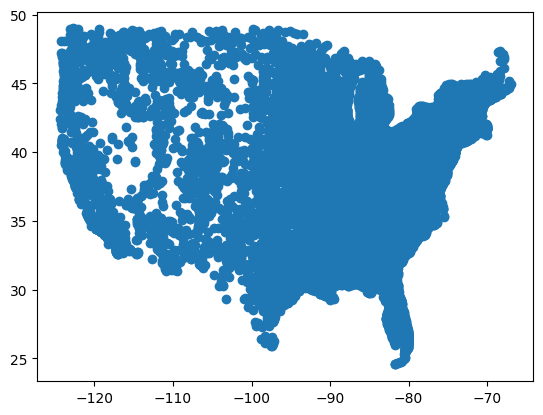

In [5]:
# visual check: 
plt.scatter(zip_df['lon'], zip_df['lat'])
print('Shape of zip_df: ', zip_df.shape)

In [6]:
zip_df

,ZIP_CODE,total_amt,n_donors,state,prop_rep,prop_dem,log_total_amt,log_n_donors,state_AE,state_AK,state_AL,state_AP,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,state_GA,state_GU,state_HI,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MP,state_MS,state_MT,state_NC,state_ND,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_PR,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VI,state_VT,state_WA,state_WI,state_WV,state_WY,state_ZZ,lat,lon
183,01001,1420.0,4,MA,0.985915,0.014085,7.259116,1.386294,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,42.0702,-72.6227
195,01002,12091.0,31,MA,0.066578,0.933422,9.400299,3.433987,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,42.3671,-72.4646
314,01003,200.0,2,MA,0.000000,1.000000,5.303305,0.693147,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,42.3919,-72.5248
321,01007,540.0,5,MA,0.166667,0.833333,6.293419,1.609438,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,42.2751,-72.4110
341,01013,662.0,2,MA,1.000000,0.000000,6.496775,0.693147,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,42.1487,-72.6079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353103,99353,1775.0,7,WA,0.966197,0.033803,7.482119,1.945910,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,46.3153,-119.3714
353120,99354,4836.0,17,WA,0.413565,0.586435,8.484050,2.833213,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,46.3257,-119.3067
353155,99362,10817.0,23,WA,0.733752,0.266248,9.288967,3.135494,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

# Fit a model using Byers / Gills approach (trying on all USA)

Linear model: log_total_amt ~ prop_rep + log_n_donors + eps
- akin to modeling donations per donor. open to choice later.

eps ~ N(0, sigma^2 H(phi) + tau^2 I)
where tau^2 is noise unrelated to distance and sigma^2 scales the correlation based on distances

H(phi) is a matrix where entries are determined by distance dij between points: H_ij = exp(-phi^2 d_ij^2) so phi determines how strong correlation is between nearby points

priors (following byers/gill):
- flat on linear model coefficients beta (computational reasons)
- uniform(6, 8) on tau^2/sigma^2 -> assumption that uncorrelated noise is like 6-8x spatial covariance
- on sigma^2: proportional to 1/sigma^2
- on 1/phi: unif(0, 9000)

fitting: PyMC uses NUTS (based on hamiltonian monte carlo) + bootstrap defined in paper

## a. one bootstrap sample to start

In [7]:
if RUN_TEST:

    import pymc as pm
    import pytensor.tensor as pt
    import numpy as np
    import arviz as az
    import matplotlib.pyplot as plt
    from scipy.spatial.distance import cdist

    n_subsample = 500
    sample = zip_df.sample(n=n_subsample, random_state=42).reset_index(drop=True)

    # drop rows with NaN in outcome or covariates
    sample = sample.dropna(subset=['log_total_amt', 'log_n_donors', 'prop_rep']).reset_index(drop=True)
    n = len(sample)

    coords = sample[['lat', 'lon']].values.astype(float)
    X = np.column_stack([
        np.ones(n),
        sample['prop_rep'].fillna(0).values,
        sample['log_n_donors'].values,
    ])
    y = sample['log_total_amt'].values
    D = cdist(coords, coords)

    with pm.Model() as model:
        log_sigma2   = pm.Flat('log_sigma2')
        sigma2       = pm.Deterministic('sigma2', pm.math.exp(log_sigma2))
        nugget_ratio = pm.Uniform('nugget_ratio', lower=6.0, upper=8.0)
        inv_phi      = pm.Uniform('inv_phi', lower=0.1, upper=9000.0)
        phi          = pm.Deterministic('phi', 1.0 / inv_phi)
        beta         = pm.Normal('beta', mu=0, sigma=100, shape=X.shape[1])
        H            = pm.math.exp(-(phi ** 2) * D ** 2)
        Sigma        = sigma2 * H + nugget_ratio * sigma2 * pt.eye(n)
        mu           = pm.math.dot(X, beta)
        y_obs        = pm.MvNormal('y_obs', mu=mu, cov=Sigma, observed=y)
        trace        = pm.sample(1000, tune=1000, chains=2, cores=1, target_accept=0.9,
                                 return_inferencedata=True)

    # --- numerical summary (R-hat, ESS, mean, sd, HDI) ---
    diag_vars = ['beta', 'sigma2', 'nugget_ratio', 'inv_phi']
    print(f"Divergences:          {int(trace.sample_stats['diverging'].values.sum())}")
    print(f"Mean acceptance rate: {float(trace.sample_stats['acceptance_rate'].values.mean()):.3f}")
    print(f"Mean step size:       {float(trace.sample_stats['step_size'].values.mean()):.4f}")
    display(az.summary(trace, var_names=diag_vars, round_to=4))

    # --- trace plots ---
    az.plot_trace(trace, var_names=diag_vars, compact=True)
    plt.suptitle('Trace plots', y=1.02)
    plt.tight_layout()
    plt.show()

    # --- rank plots (uniform bars = good chain mixing) ---
    az.plot_rank(trace, var_names=diag_vars)
    plt.suptitle('Rank plots')
    plt.tight_layout()
    plt.show()

    # --- energy plot (BFMI; should be > 0.2 for good geometry exploration) ---
    az.plot_energy(trace)
    plt.show()

## b. BRSS proper 

In a bootstrap loop

In [8]:
if RUN_FIRST_TIME:

    import arviz as az

    B = 100
    results = []

    for b in range(B):
        sample = zip_df.sample(n=n_subsample, random_state=b).reset_index(drop=True)
        sample = sample.dropna(subset=['log_total_amt', 'log_n_donors', 'prop_rep']).reset_index(drop=True)
        n = len(sample)

        coords = sample[['lat', 'lon']].values.astype(float)
        X = np.column_stack([np.ones(n),
                            sample['prop_rep'].fillna(0).values,
                            sample['log_n_donors'].values])
        y = sample['log_total_amt'].values
        D = cdist(coords, coords)

        with pm.Model() as model:
            log_sigma2    = pm.Flat('log_sigma2')
            sigma2        = pm.Deterministic('sigma2', pm.math.exp(log_sigma2))
            nugget_ratio  = pm.Uniform('nugget_ratio', lower=6.0, upper=8.0)
            inv_phi       = pm.Uniform('inv_phi', lower=0.1, upper=9000.0)
            phi           = pm.Deterministic('phi', 1.0 / inv_phi)
            beta          = pm.Normal('beta', mu=0, sigma=100, shape=3)
            H             = pm.math.exp(-(phi**2) * D**2)
            Sigma         = sigma2 * H + nugget_ratio * sigma2 * pt.eye(n)
            mu            = pm.math.dot(X, beta)
            _             = pm.MvNormal('y_obs', mu=mu, cov=Sigma, observed=y)
            trace         = pm.sample(1000, tune=500, chains=2, cores=1,
                                    progressbar=False, return_inferencedata=True)

        # record posterior means for this bootstrap sample
        post = trace.posterior
        results.append({
            'beta':         post['beta'].values.mean(axis=(0, 1)),
            'sigma2':       float(post['sigma2'].values.mean()),
            'nugget_ratio': float(post['nugget_ratio'].values.mean()),
            'inv_phi':      float(post['inv_phi'].values.mean()),
        })

    # --- aggregate across bootstrap samples ---
    betas    = np.array([r['beta'] for r in results])
    sigma2s  = np.array([r['sigma2'] for r in results])
    inv_phis = np.array([r['inv_phi'] for r in results])

    print("beta means:", betas.mean(axis=0))
    print("beta std:",   betas.std(axis=0))
    print("sigma2:",     sigma2s.mean(), "±", sigma2s.std())
    print("inv_phi:",    inv_phis.mean(), "±", inv_phis.std())

    import pickle, pathlib

    out_path = pathlib.Path('results_bootstrap.pkl')
    with open(out_path, 'wb') as f:
        pickle.dump(results, f)

    print(f"Saved {len(results)} bootstrap results to {out_path.resolve()}")

else:

    import pickle
    with open('results_bootstrap.pkl', 'rb') as f:
        results = pickle.load(f)

In [9]:
if RUN_FIRST_TIME:

    import pickle, pathlib

    out_path = pathlib.Path('results_bootstrap.pkl')
    with open(out_path, 'wb') as f:
        pickle.dump(results, f)

    print(f"Saved {len(results)} bootstrap results to {out_path.resolve()}")

# look at results

Accidentally didn't save all the diagnostics but we can look at the plots to get a sense.

In [10]:
import pandas as pd
import numpy as np

betas    = np.array([r['beta'] for r in results])
sigma2s  = np.array([r['sigma2'] for r in results])
inv_phis = np.array([r['inv_phi'] for r in results])
nuggets  = np.array([r['nugget_ratio'] for r in results])

params = {
    'intercept':    betas[:, 0],
    'prop_rep':     betas[:, 1],
    'log_n_donors': betas[:, 2],
    'sigma2':       sigma2s,
    'inv_phi':      inv_phis,
    'nugget_ratio': nuggets,
}

rows = []
for name, vals in params.items():
    rows.append({
        'parameter': name,
        'mean':  vals.mean(),
        'std':   vals.std(),
        '2.5%':  np.percentile(vals, 2.5),
        '97.5%': np.percentile(vals, 97.5),
    })

pd.DataFrame(rows).set_index('parameter').round(4)

,mean,std,2.5%,97.5%
parameter,,,,
intercept,5.1227,0.0981,4.9141,5.3091
prop_rep,0.3827,0.1071,0.1872,0.5852
log_n_donors,1.2461,0.0277,1.1950,1.3076
sigma2,0.1088,0.0103,0.0916,0.1272
inv_phi,4543.0392,75.1009,4409.5185,4659.6166
nugget_ratio,6.9995,0.0159,6.9672,7.0253


The covariates all make sense, but the spatial parameter fits weren't great. inv_phi is the range parameter (decay) and it's very large, so basically the spatial correlation isn't decaying over distances (not what we want). meanwhile nugget ratio is basically just stuck to the prior. will need to rerun. 

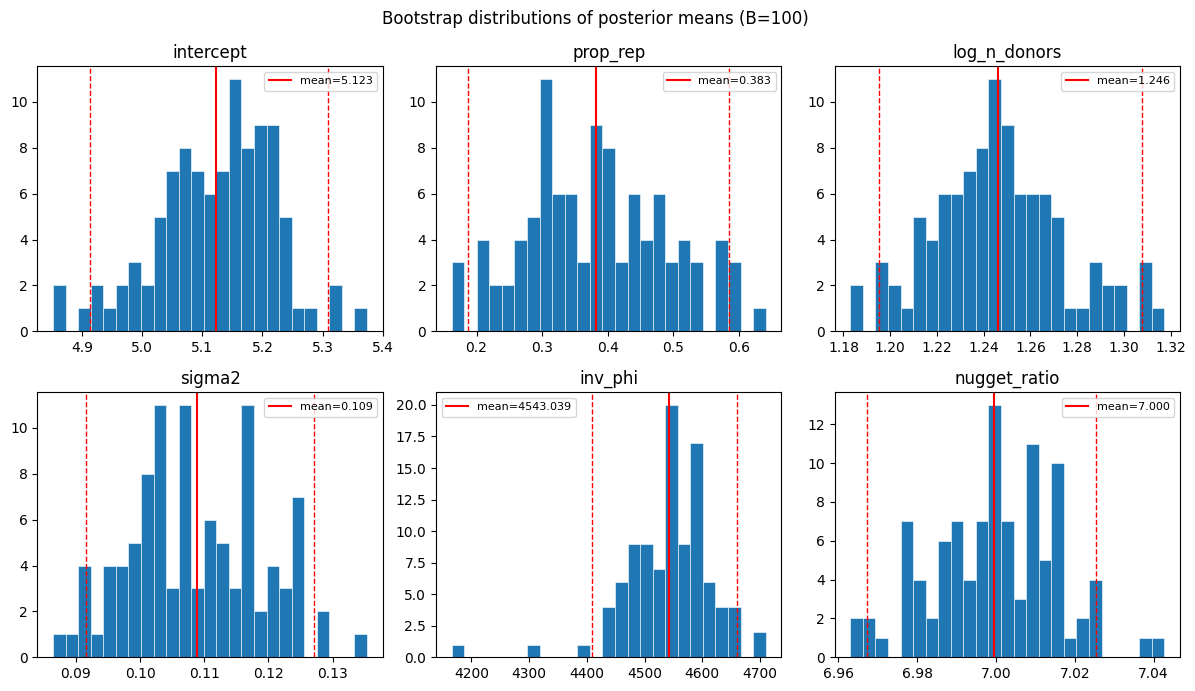

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for ax, (name, vals) in zip(axes, params.items()):
    ax.hist(vals, bins=25, edgecolor='white', linewidth=0.4)
    ax.axvline(vals.mean(), color='red', linewidth=1.5, label=f'mean={vals.mean():.3f}')
    ax.axvline(np.percentile(vals, 2.5),  color='red', linewidth=1, linestyle='--')
    ax.axvline(np.percentile(vals, 97.5), color='red', linewidth=1, linestyle='--')
    ax.set_title(name)
    ax.legend(fontsize=8)

fig.suptitle('Bootstrap distributions of posterior means (B=100)', fontsize=12)
plt.tight_layout()
plt.show()

# Attempt 2 to fit a model with meaningful spatial correlation

Subset to california
choose different priors

In [12]:
zip_df

,ZIP_CODE,total_amt,n_donors,state,prop_rep,prop_dem,log_total_amt,log_n_donors,state_AE,state_AK,state_AL,state_AP,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,state_GA,state_GU,state_HI,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MP,state_MS,state_MT,state_NC,state_ND,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_PR,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VI,state_VT,state_WA,state_WI,state_WV,state_WY,state_ZZ,lat,lon
183,01001,1420.0,4,MA,0.985915,0.014085,7.259116,1.386294,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,42.0702,-72.6227
195,01002,12091.0,31,MA,0.066578,0.933422,9.400299,3.433987,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,42.3671,-72.4646
314,01003,200.0,2,MA,0.000000,1.000000,5.303305,0.693147,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,42.3919,-72.5248
321,01007,540.0,5,MA,0.166667,0.833333,6.293419,1.609438,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,42.2751,-72.4110
341,01013,662.0,2,MA,1.000000,0.000000,6.496775,0.693147,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,42.1487,-72.6079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353103,99353,1775.0,7,WA,0.966197,0.033803,7.482119,1.945910,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,46.3153,-119.3714
353120,99354,4836.0,17,WA,0.413565,0.586435,8.484050,2.833213,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,46.3257,-119.3067
353155,99362,10817.0,23,WA,0.733752,0.266248,9.288967,3.135494,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

california rows:  1606


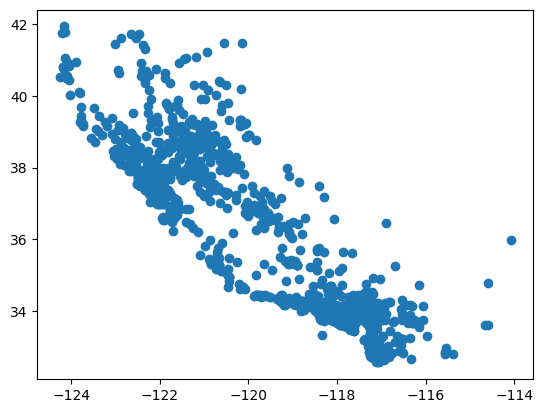

norcal rows:  161


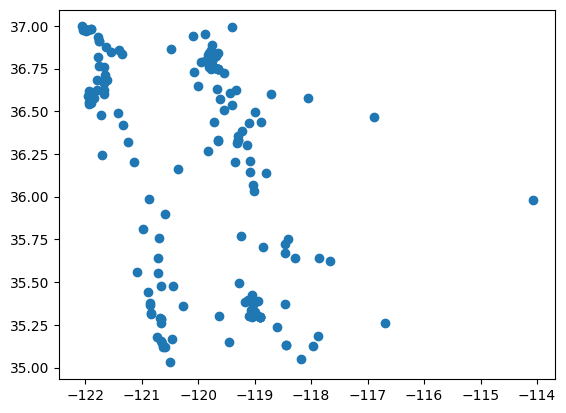

In [13]:
# subset to CA
california = zip_df[(zip_df['state'] == 'CA') &
                    (zip_df['lon'] <= -100)]

norcal = zip_df[
    (zip_df['state'] == 'CA') &
    (zip_df['lat'] >= 35) &
    (zip_df['lat'] <= 37)
    ]

print('california rows: ', california.shape[0])
plt.scatter(california['lon'], california['lat'])
plt.show()

print('norcal rows: ', norcal.shape[0])
plt.scatter(norcal['lon'], norcal['lat'])
plt.show()

In [14]:
# helper function
import pymc as pm
import pytensor.tensor as pt
import numpy as np
from scipy.spatial.distance import cdist


def fit_spatial_model(
    df,
    draws=1000,
    tune=1000,
    chains=2,
    target_accept=0.9,
    nugget_ratio_bounds=(6.0, 8.0),
    inv_phi_bounds=(0.1, 9000.0),
    beta_sigma=100.0,
    n_prior_samples=500,
    include_donors=True,
    **pm_kwargs
):
    """
    Returns a fully-populated arviz.InferenceData containing:
      posterior          — all parameter draws
      sample_stats       — divergences, acceptance rate, step size, tree depth, energy
      log_likelihood     — log p(y | theta) per draw (for WAIC / LOO)
      posterior_predictive — y_obs draws from posterior
      prior              — prior parameter samples
      prior_predictive   — y_obs draws from prior
      observed_data      — the actual y values
    """
    sample = df.dropna(subset=['log_total_amt', 'log_n_donors', 'prop_rep',
                                'lat', 'lon']).reset_index(drop=True)
    n = len(sample)

    coords = sample[['lat', 'lon']].values.astype(float)

    if include_donors:
        X = np.column_stack([
            np.ones(n),
            sample['prop_rep'].values,
            sample['log_n_donors'].values,
        ])
        prior_shape = 3
    else:
        X = np.column_stack([
            np.ones(n),
            sample['prop_rep'].values
        ])
        prior_shape = 2
        
    y = sample['log_total_amt'].values
    D = cdist(coords, coords)

    with pm.Model() as model:
        # pm.Flat has no rng_fn so prior predictive fails; wide Normal is
        # functionally identical for MCMC and covers sigma2 in [1e-9, 1e8]
        log_sigma2   = pm.Normal('log_sigma2', mu=0, sigma=10)
        sigma2       = pm.Deterministic('sigma2', pm.math.exp(log_sigma2))
        nugget_ratio = pm.Uniform('nugget_ratio',
                                  lower=nugget_ratio_bounds[0],
                                  upper=nugget_ratio_bounds[1])
        inv_phi      = pm.Uniform('inv_phi',
                                  lower=inv_phi_bounds[0],
                                  upper=inv_phi_bounds[1])
        phi          = pm.Deterministic('phi', 1.0 / inv_phi)
        beta         = pm.Normal('beta', mu=0, sigma=beta_sigma, shape=prior_shape)

        H     = pm.math.exp(-(phi ** 2) * D ** 2)
        Sigma = sigma2 * H + nugget_ratio * sigma2 * pt.eye(n)
        mu    = pm.math.dot(X, beta)
        _     = pm.MvNormal('y_obs', mu=mu, cov=Sigma, observed=y)

        # prior predictive
        prior = pm.sample_prior_predictive(samples=n_prior_samples)

        # posterior + log likelihood + sample stats
        # cores=1 avoids multiprocessing EOFError in Jupyter on macOS
        trace = pm.sample(draws, tune=tune, chains=chains, cores=1,
                          target_accept=target_accept,
                          idata_kwargs={'log_likelihood': True},
                          return_inferencedata=True, **pm_kwargs)

        # posterior predictive
        pm.sample_posterior_predictive(trace, extend_inferencedata=True)

    trace.extend(prior)
    return trace

In [ ]:
trace_norcal = fit_spatial_model(
    norcal,
    draws=1000,
    tune=1000,
    chains=4,
    target_accept=0.9,
    nugget_ratio_bounds=(1.0, 20.0),  # wider — let data decide nugget
    inv_phi_bounds=(0.1, 10.0),       # CA spans ~10° lat/lon, cap range there
    beta_sigma=100.0,
    n_prior_samples=100,
)

Sampling: [beta, inv_phi, log_sigma2, nugget_ratio, y_obs]
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [log_sigma2, nugget_ratio, inv_phi, beta]


/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Divergences:          0
Mean acceptance rate: 0.912  (target ≥ 0.90)
Mean step size:       0.1341
Max tree depth:       6  (flag if ≥ 10)

--- Parameter summary (R-hat should be < 1.01, ESS > 400) ---


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],4.9638,0.2716,4.4877,5.4866,0.0059,0.0069,2239.6409,1832.3961,1.0023
beta[1],0.8205,0.1767,0.4880,1.1366,0.0031,0.0034,3270.4079,2287.5558,1.0015
beta[2],1.1569,0.0500,1.0659,1.2518,0.0010,0.0008,2711.1312,2330.1948,1.0010
sigma2,0.0733,0.0737,0.0216,0.1940,0.0024,0.0046,1192.1541,1264.2979,0.9999
nugget_ratio,11.2616,5.3069,2.7681,19.9995,0.1477,0.0611,1228.0179,1328.0662,1.0002
inv_phi,5.4444,2.7123,1.0511,9.9974,0.0498,0.0356,2712.3905,1709.6872,1.0006


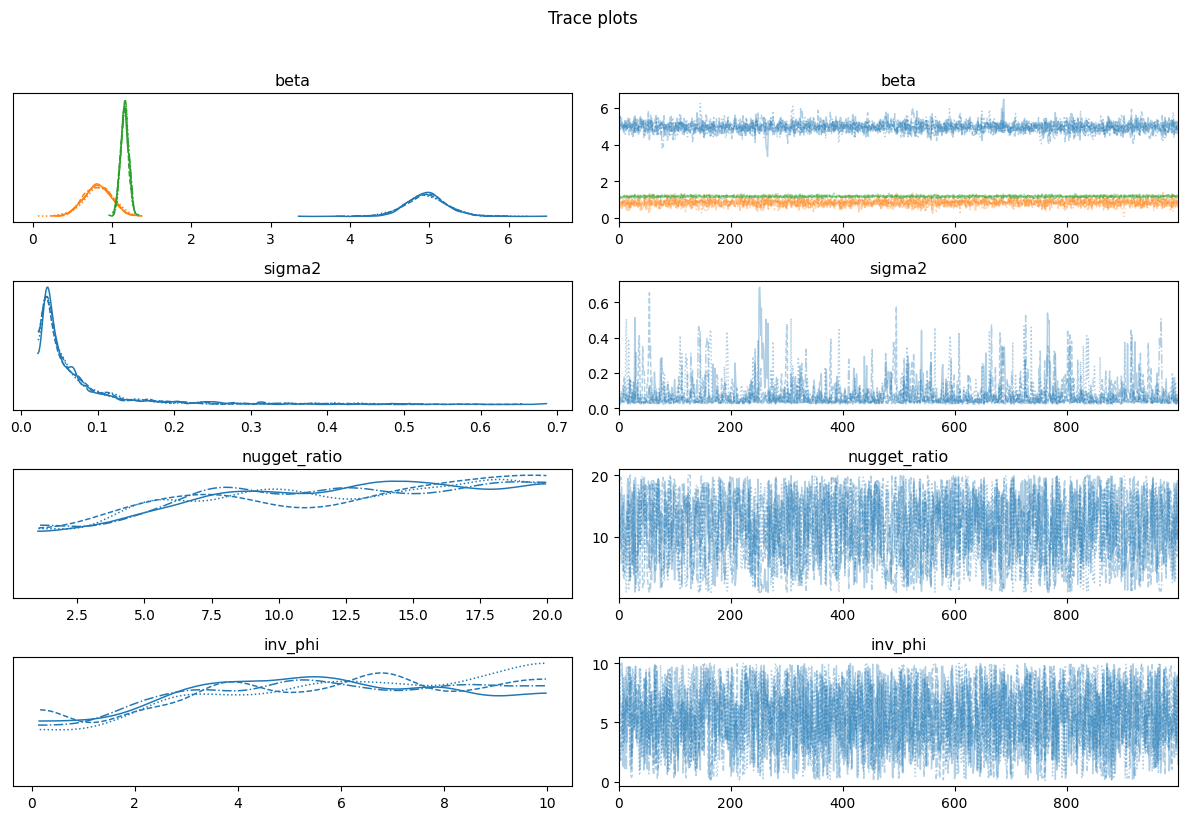

In [19]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

diag_vars = ['beta', 'sigma2', 'nugget_ratio', 'inv_phi']

# --- 1. scalar MCMC health metrics ---
n_div   = int(trace_norcal.sample_stats['diverging'].values.sum())
acc     = float(trace_norcal.sample_stats['acceptance_rate'].values.mean())
ss      = float(trace_norcal.sample_stats['step_size'].values.mean())
max_td  = int(trace_norcal.sample_stats['tree_depth'].values.max())

print(f"Divergences:          {n_div}")
print(f"Mean acceptance rate: {acc:.3f}  (target ≥ 0.90)")
print(f"Mean step size:       {ss:.4f}")
print(f"Max tree depth:       {max_td}  (flag if ≥ 10)")

# --- 2. R-hat / ESS table ---
print("\n--- Parameter summary (R-hat should be < 1.01, ESS > 400) ---")
display(az.summary(trace_norcal, var_names=diag_vars, round_to=4))

# --- 3. trace plots ---
az.plot_trace(trace_norcal, var_names=diag_vars, compact=True)
plt.suptitle('Trace plots', y=1.02)
plt.tight_layout()
plt.show()

The above took 2 minutes. All good on convergence, but the prior boundaries are getting hit, so I don't trust the results. 

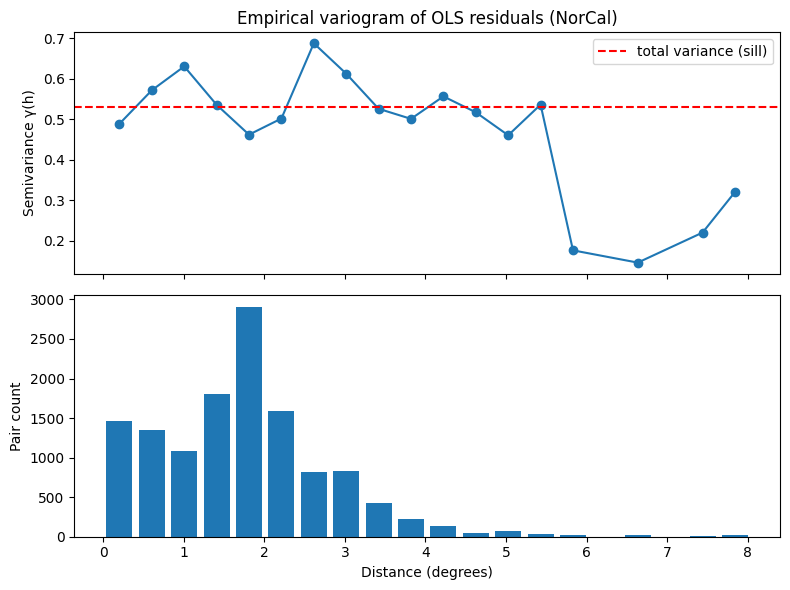

Variance of residuals: 0.5296
Nugget (first bin γ):  0.4892  (92.4% of sill)


In [15]:
# first check empirical variogram to see if we should expect the spatial model to be any good

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression

# 1. OLS residuals (remove mean structure before checking spatial correlation)
sub = norcal.dropna(subset=['log_total_amt', 'log_n_donors', 'prop_rep', 'lat', 'lon'])
X_ols = sub[['prop_rep', 'log_n_donors']].values
y_ols = sub['log_total_amt'].values
resid = y_ols - LinearRegression().fit(X_ols, y_ols).predict(X_ols)

# 2. Pairwise distances (degrees; ~111 km per degree lat)
coords = sub[['lat', 'lon']].values
D = cdist(coords, coords)

# 3. Semivariance: γ(h) = 0.5 * mean((r_i - r_j)^2) for pairs in bin
i_idx, j_idx = np.tril_indices(len(resid), k=-1)
dists = D[i_idx, j_idx]
sq_diffs = (resid[i_idx] - resid[j_idx]) ** 2

n_bins = 20
bin_edges = np.linspace(0, dists.max(), n_bins + 1)
bin_centers, semivar, counts = [], [], []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (dists >= lo) & (dists < hi)
    if mask.sum() > 10:
        bin_centers.append((lo + hi) / 2)
        semivar.append(0.5 * sq_diffs[mask].mean())
        counts.append(mask.sum())

bin_centers = np.array(bin_centers)
semivar = np.array(semivar)

# 4. Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(bin_centers, semivar, 'o-')
ax1.axhline(resid.var(), color='red', linestyle='--', label='total variance (sill)')
ax1.set_ylabel('Semivariance γ(h)')
ax1.set_title('Empirical variogram of OLS residuals (NorCal)')
ax1.legend()

ax2.bar(bin_centers, counts, width=np.diff(bin_edges)[0] * 0.8)
ax2.set_xlabel('Distance (degrees)')
ax2.set_ylabel('Pair count')

plt.tight_layout()
plt.show()

print(f"Variance of residuals: {resid.var():.4f}")
print(f"Nugget (first bin γ):  {semivar[0]:.4f}  ({100*semivar[0]/resid.var():.1f}% of sill)")


The above graph is saying that we're screwed, the spatial correlation is basically not there. 

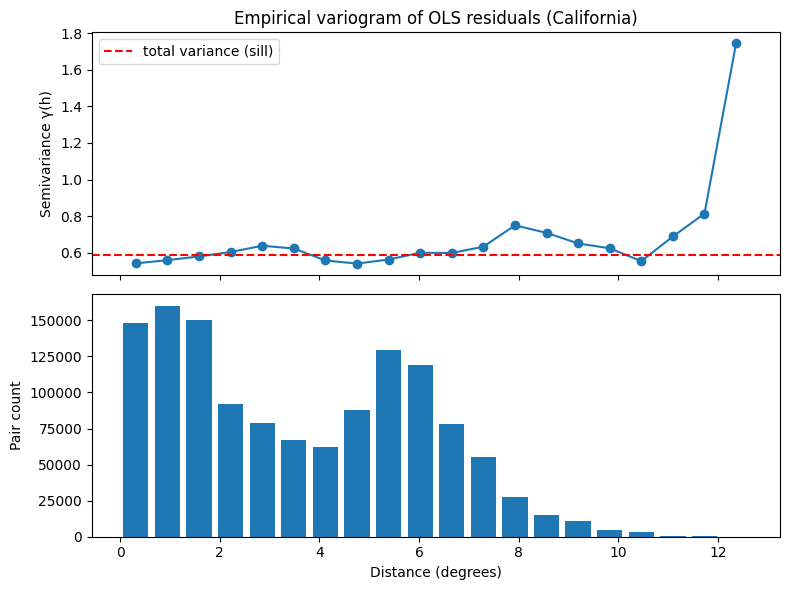

Variance of residuals: 0.5859
Nugget (first bin γ):  0.5420  (92.5% of sill)


In [16]:
# try the same on california

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression

# 1. OLS residuals (remove mean structure before checking spatial correlation)
sub = california.dropna(subset=['log_total_amt', 'log_n_donors', 'prop_rep', 'lat', 'lon'])
X_ols = sub[['prop_rep', 'log_n_donors']].values
y_ols = sub['log_total_amt'].values
resid = y_ols - LinearRegression().fit(X_ols, y_ols).predict(X_ols)

# 2. Pairwise distances (degrees; ~111 km per degree lat)
coords = sub[['lat', 'lon']].values
D = cdist(coords, coords)

# 3. Semivariance: γ(h) = 0.5 * mean((r_i - r_j)^2) for pairs in bin
i_idx, j_idx = np.tril_indices(len(resid), k=-1)
dists = D[i_idx, j_idx]
sq_diffs = (resid[i_idx] - resid[j_idx]) ** 2

n_bins = 20
bin_edges = np.linspace(0, dists.max(), n_bins + 1)
bin_centers, semivar, counts = [], [], []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (dists >= lo) & (dists < hi)
    if mask.sum() > 10:
        bin_centers.append((lo + hi) / 2)
        semivar.append(0.5 * sq_diffs[mask].mean())
        counts.append(mask.sum())

bin_centers = np.array(bin_centers)
semivar = np.array(semivar)

# 4. Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(bin_centers, semivar, 'o-')
ax1.axhline(resid.var(), color='red', linestyle='--', label='total variance (sill)')
ax1.set_ylabel('Semivariance γ(h)')
ax1.set_title('Empirical variogram of OLS residuals (California)')
ax1.legend()

ax2.bar(bin_centers, counts, width=np.diff(bin_edges)[0] * 0.8)
ax2.set_xlabel('Distance (degrees)')
ax2.set_ylabel('Pair count')

plt.tight_layout()
plt.show()

print(f"Variance of residuals: {resid.var():.4f}")
print(f"Nugget (first bin γ):  {semivar[0]:.4f}  ({100*semivar[0]/resid.var():.1f}% of sill)")


Same here. Try USA:

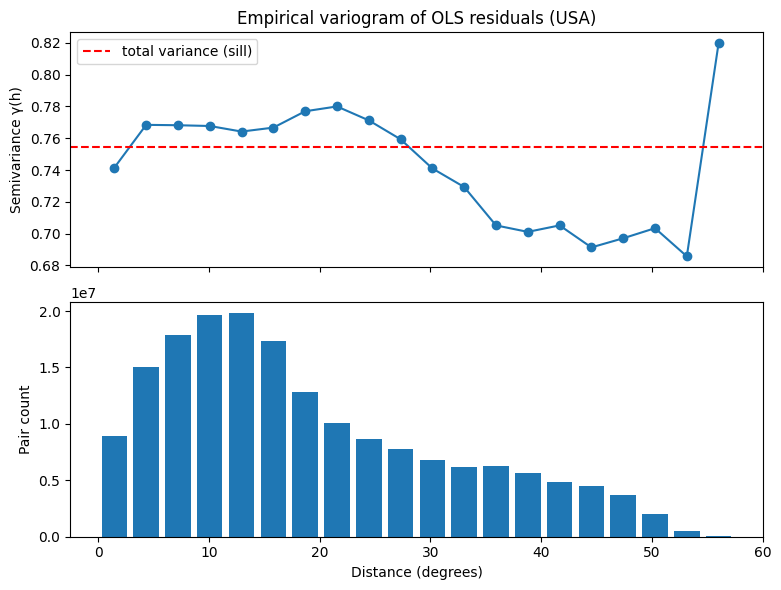

Variance of residuals: 0.7545
Nugget (first bin γ):  0.7415  (98.3% of sill)


In [17]:
# try the same on usa

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression

# 1. OLS residuals (remove mean structure before checking spatial correlation)
sub = zip_df.dropna(subset=['log_total_amt', 'log_n_donors', 'prop_rep', 'lat', 'lon'])
X_ols = sub[['prop_rep', 'log_n_donors']].values
y_ols = sub['log_total_amt'].values
resid = y_ols - LinearRegression().fit(X_ols, y_ols).predict(X_ols)

# 2. Pairwise distances (degrees; ~111 km per degree lat)
coords = sub[['lat', 'lon']].values
D = cdist(coords, coords)

# 3. Semivariance: γ(h) = 0.5 * mean((r_i - r_j)^2) for pairs in bin
i_idx, j_idx = np.tril_indices(len(resid), k=-1)
dists = D[i_idx, j_idx]
sq_diffs = (resid[i_idx] - resid[j_idx]) ** 2

n_bins = 20
bin_edges = np.linspace(0, dists.max(), n_bins + 1)
bin_centers, semivar, counts = [], [], []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (dists >= lo) & (dists < hi)
    if mask.sum() > 10:
        bin_centers.append((lo + hi) / 2)
        semivar.append(0.5 * sq_diffs[mask].mean())
        counts.append(mask.sum())

bin_centers = np.array(bin_centers)
semivar = np.array(semivar)

# 4. Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(bin_centers, semivar, 'o-')
ax1.axhline(resid.var(), color='red', linestyle='--', label='total variance (sill)')
ax1.set_ylabel('Semivariance γ(h)')
ax1.set_title('Empirical variogram of OLS residuals (USA)')
ax1.legend()

ax2.bar(bin_centers, counts, width=np.diff(bin_edges)[0] * 0.8)
ax2.set_xlabel('Distance (degrees)')
ax2.set_ylabel('Pair count')

plt.tight_layout()
plt.show()

print(f"Variance of residuals: {resid.var():.4f}")
print(f"Nugget (first bin γ):  {semivar[0]:.4f}  ({100*semivar[0]/resid.var():.1f}% of sill)")


Welp. 